# Exploring single-cell TCR/BCR data with Dandelion
## Goals
- Understand single-cell TCR/BCR sequencing (V(D)J data)
- Get familiar with the AIRR format
- Use Dandelion to load, QC and call clonotypes
- Integrate TCR information back into a Scanpy AnnData
- Visualize clonal expansion as a clonotype network and on UMAP

## Dandelion: a package for analyzing single cell BCR/TCR data

[Dandelion](https://sc-dandelion.readthedocs.io) is a Python package for analysing single-cell BCR/TCR V(D)J-seq data. It can:

- read the raw outputs above (`.fasta` and `.csv`, or AIRR `.tsv`) into a structured `Dandelion` object
- (re)annotate contigs with IgBLAST for more accurate V/D/J gene calls
- QC contigs and flag problematic cells (doublets, orphan chains, …)
- define clonotypes based on V/J gene + CDR3 identity
- build a clonotype network showing which cells share TCRs
- integrate seamlessly with Scanpy, as TCR info is pushed into `adata.obs` so it can be plotted on the GEX UMAP

A `Dandelion` object holds two linked tables:
- `.data` - one row per contig (the AIRR table)
- `.metadata` - one row per cell, summarising its chain composition

In this tutorial we skip the assembly and IgBLAST steps: the `.zipddl` files (Dandelion's compressed native format) we'll load have already been built from the CSV/FASTA outputs upstream, so we can jump straight into analysis. The matched gene-expression data has likewise been saved as `AnnData` (`.h5ad`).

### Install Dandelion and dependencies

In [1]:
!pip install -qqq scanpy[leiden] numpy==2.0.2 pandas==2.2.2
!pip install -qqq "sc-dandelion[polars] @ git+https://github.com/tuonglab/dandelion.git"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 107.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.8/116.8 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.3/160.3 kB 10.8 MB/s eta 0:00:00
  Installing build dependencies ... 

In [2]:
import scanpy as sc
import polars as pl
import numpy as np
import anndata as ad
import dandelion as ddl
import matplotlib.pyplot as plt

## A quick primer on TCR/BCR sequencing

T cells recognise antigens through their T cell receptor (TCR), a heterodimer of two chains, typically `α (alpha)` and `β (beta)` in conventional T cells. B cells do so through the B cell receptor (BCR), consisting of a `heavy chain` and `light chain`.

Each chain is built by recombining one `V`, ((for β and Heavy chain only) one `D` gene segment) and one `J`, with random nucleotides added at the junctions. This process generates a highly diverse repertoire of `CDR3` sequences that underpins antigen recognition.

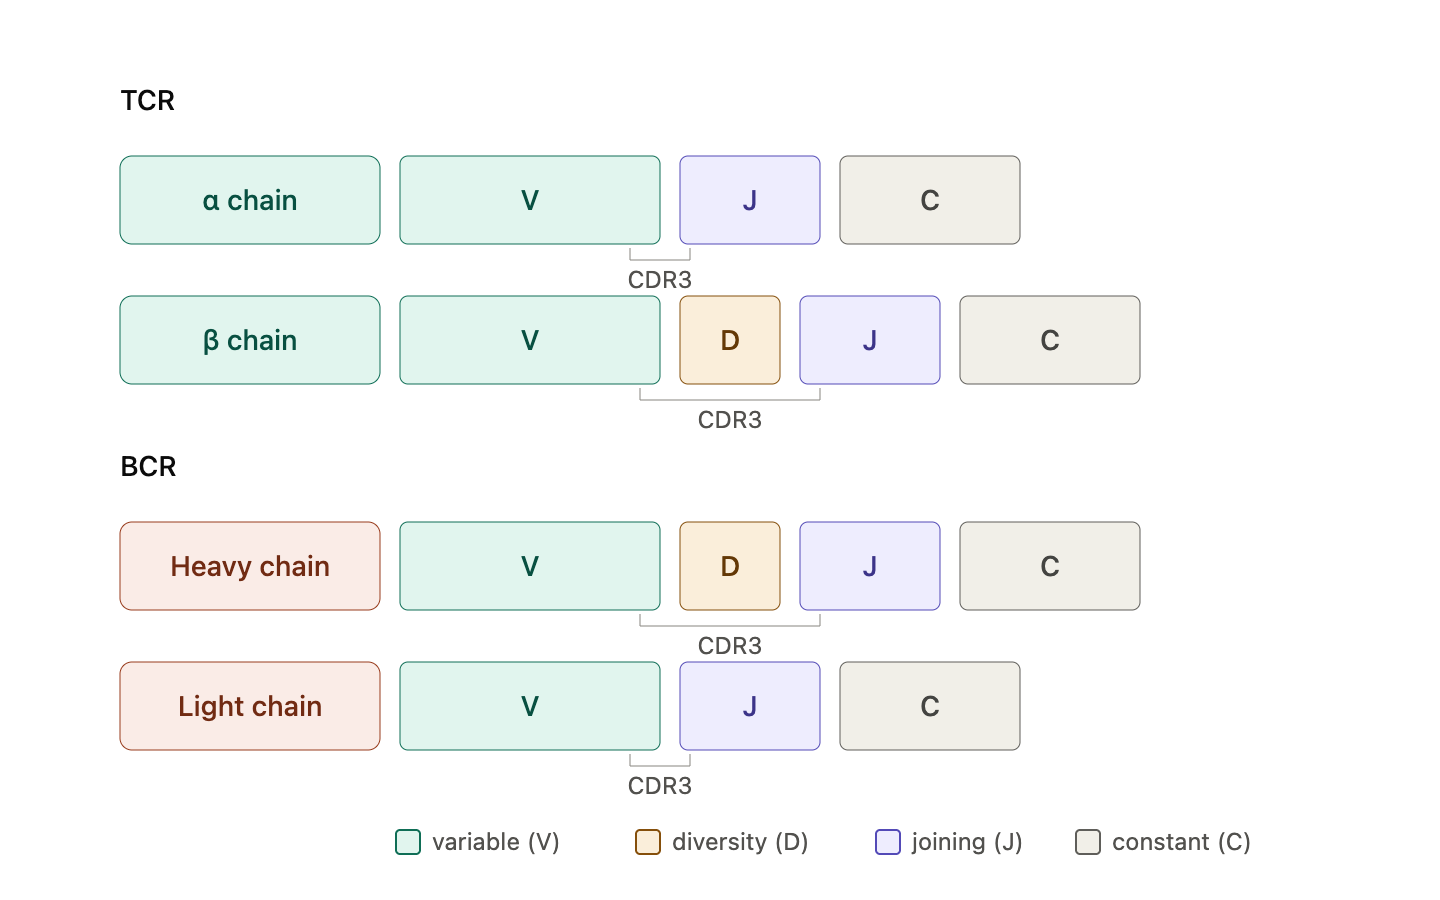

Key terms we'll use throughout:

- `Contig` - one assembled TCR/BCR transcript (one chain) detected in one cell
- `AIRR format` - the community-standard tabular format for V(D)J data
- `Productive` - a contig with an in-frame, intact CDR3 (a working chain)
- `Clonotype` - a group of cells sharing the same TCR/BCR (clonal progeny of one ancestor T/B cell).

### How does V(D)J data actually reach us?

A single-cell 5′ experiment (10x Genomics, SeekGene, etc.) produces two libraries from the same cells: a gene-expression library and an enriched V(D)J library. The outputs are typically:

- `*_contig.fasta` - the assembled contig sequences (nucleotides)
- `*_annotations.csv` - a table with one row per contig: cell barcode, V/D/J gene calls, CDR3 sequence, productive flag, UMI count, …

<img src="https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs41592-024-02243-4/MediaObjects/41592_2024_2243_Fig1_HTML.png">

## Let's look at some real data

## Download the data

In [3]:
import gdown

datasets = {
    "SeekGene1": "15AlNiZX2O9nSAf7meDm2Tr9UCnbtFOxo",
    "SeekGene2": "1lM1SbR1PHApq_bbzlN-WpW-WMGff6xg5",
}

for foldername, folder_id in datasets.items():
    print(f"Downloading {foldername}")
    gdown.download_folder(
        id=folder_id,
        output=str(foldername),
        quiet=True,
        use_cookies=False
    )

## View the raw TCR data

In [4]:
!ls SeekGene1

all_contig_annotations.csv  all_contig.fasta


In [5]:
import pandas as pd

df = pd.read_csv('SeekGene1/all_contig_annotations.csv')
df.head()

,barcode,contig_id,length,chain,v_gene,d_gene,j_gene,c_gene,productive,cdr3,cdr3_nt,reads,umis
0,AAACCAAAGAAAGTGC-1,AAACCAAAGAAAGTGC-1_contig_1,494,TRB,TRBV2*01,NaN,TRBJ2-7*01,TRBC2,True,CASSGQGNYEQYF,TGTGCCAGCAGTGGACAGGGAAACTACGAGCAGTACTTC,3032,15
1,AAACCAAAGAAAGTGC-1,AAACCAAAGAAAGTGC-1_contig_2,570,TRA,TRAV12-1*01,NaN,TRAJ4*01,TRAC,True,CVVSQGGYNKLIF,TGTGTGGTGTCCCAAGGCGGCTACAATAAGCTGATTTTT,1494,7
2,AAACCAAAGAAAGTGC-1,AAACCAAAGAAAGTGC-1_contig_3,507,TRB,TRBV7-2*01,TRBD2*01,TRBJ2-4*01,TRBC2,False,CASSTSGGA*PKTFST,TGTGCCAGCAGCACTAGCGGGGGGGCCTAGCCAAAAACATTCAGTA...,967,5
3,AAACCAAAGGTCACGT-1,AAACCAAAGGTCACGT-1_contig_1,505,TRB,TRBV7-2*02,NaN,TRBJ2-3*01,TRBC2,True,CASSLFPEAFTDTQYF,TGTGCCAGCAGCTTATTTCCAGAAGCTTTCACAGATACGCAGTATTTT,3888,22
4,AAACCAAAGGTCACGT-1,AAACCAAAGGTCACGT-1_contig_2,613,TRA,TRAV8-6*02,NaN,TRAJ18*01,TRAC,True,CAVNGRGSTLGRLYF,TGTGCTGTGAATGGTAGAGGCTCAACCCTGGGGAGGCTATACTTT,746,5


### 🗣️ Think, pair, share 🏋️ Exercise! - Looking at data

What do each of the columns mean?

  - Which id is relevant?

  - Which columns are essential for defining a clonotype?

  - How many contigs does a cell have?

  - What does `productive = False` mean


In [20]:
# Let's zoom into one one cell



In [21]:
# Before we define a clone, should we keep every row in this table, or filter some out first? What would you filter on, and why?



### 🗣️ Think, pair, share 🏋️ Exercise! - Defining a clonotype


In [22]:
# Goal: work through a strategy to define clones



## Now to try with `Dandelion`

In [6]:
# File download
print("Downloading adata_processed.h5ad")
gdown.download(
    url="https://drive.google.com/uc?id=1s7KYUlfYwatZz4Vhc09VkWwkhDYgZUMN",
    output="adata_processed.h5ad",
    quiet=True
)

adata = sc.read_h5ad("adata_processed.h5ad")
adata

AnnData object with n_obs × n_vars = 24825 × 1000
    obs: 'sample_id', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cell_type_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'sample_id_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

## Read in as a dandelion object

In [7]:
vdj = ddl.read_vdj("SeekGene1")
vdj

Lazy Dandelion object with n_obs = 7689 and n_contigs = 19286
    data: cell_id, sequence_id, sequence_length_10x, locus, v_call, d_call, j_call, c_call, productive, junction_aa, junction, consensus_count, umi_count, sequence, rearrangement_status
    metadata: cell_id, locus_VDJ, locus_VJ, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, productive_VDJ, productive_VJ, junction_aa_VDJ, junction_aa_VJ, junction_VDJ, junction_VJ, umi_count_VDJ, umi_count_VJ, locus_VDJ_main, locus_VJ_main, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_VJ_main, productive_VDJ_main, productive_VJ_main, junction_aa_VDJ_main, junction_aa_VJ_main, junction_VDJ_main, junction_VJ_main, umi_count_VDJ_main, umi_count_VJ_main, locus_status, chain_status, rearrangement_status_VDJ, rearrangement_status_VJ

<img src="https://sc-dandelion.readthedocs.io/en/latest/_images/dandelion_class2.png">

### The AIRR table `vdj.data`

The actual TCR information lives in `vdj.data` -- a long-format table where each row is one contig (one chain in one cell).

A cell with a complete αβ TCR shows up as two rows: one for the β (VDJ) chain and one for the α (VJ) chain. Cells with extra chains have more rows.

> Note: in recent versions of Dandelion, `vdj.data` is a polars LazyFrame. This update allows Dandelion to run way much faster than the old pandas version.
> Just remember, to actually see the data of a polars LazyFrame, we need to call `.collect()`.

In [8]:
print(type(vdj.data.collect()))
print(vdj.data.collect())
print("columns:", vdj.data.collect().columns)

<class 'polars.dataframe.frame.DataFrame'>
shape: (19_286, 15)
┌────────────┬────────────┬────────────┬───────┬───┬───────────┬───────────┬───────────┬───────────┐
│ cell_id    ┆ sequence_i ┆ sequence_l ┆ locus ┆ … ┆ consensus ┆ umi_count ┆ sequence  ┆ rearrange │
│ ---        ┆ d          ┆ ength_10x  ┆ ---   ┆   ┆ _count    ┆ ---       ┆ ---       ┆ ment_stat │
│ str        ┆ ---        ┆ ---        ┆ str   ┆   ┆ ---       ┆ i64       ┆ str       ┆ us        │
│            ┆ str        ┆ i64        ┆       ┆   ┆ i64       ┆           ┆           ┆ ---       │
│            ┆            ┆            ┆       ┆   ┆           ┆           ┆           ┆ str       │
╞════════════╪════════════╪════════════╪═══════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ AAACCAAAGA ┆ AAACCAAAGA ┆ 494        ┆ TRB   ┆ … ┆ 3032      ┆ 15        ┆ AGATGCCTG ┆ Standard  │
│ AAGTGC-1   ┆ AAGTGC-1_c ┆            ┆       ┆   ┆           ┆           ┆ AGCTAGGAA ┆           │
│            ┆ ontig_1    ┆ 

The columns we'll actually use most:

| column | meaning |
|---|---|
| `cell_id` | which cell this contig came from |
| `locus` | `TRA` (α chain) or `TRB` (β chain) |
| `productive` | does this contig encode a functional chain? |
| `v_call`, `d_call`, `j_call` | the V / D / J gene segments used |
| `clone_id` | The clonotype assignment |
| `junction` | the CDR3 nucleotide sequence |
| `junction_aa` | the CDR3 amino-acid sequence |
| `umi_count` | how many UMIs (unique RNA molecules) support this contig |

In [9]:
# Preview a few rows
key_cols = [
    "cell_id",
    "locus",
    "productive",
    "v_call",
    "j_call",
    # "clone_id", # not in this object at the moment
    "junction",
    "junction_aa",
    "umi_count",
]
print(vdj.data.collect().select(key_cols).head(5))

shape: (5, 8)
┌─────────────┬───────┬────────────┬────────────┬────────────┬────────────┬────────────┬───────────┐
│ cell_id     ┆ locus ┆ productive ┆ v_call     ┆ j_call     ┆ junction   ┆ junction_a ┆ umi_count │
│ ---         ┆ ---   ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ a          ┆ ---       │
│ str         ┆ str   ┆ str        ┆ str        ┆ str        ┆ str        ┆ ---        ┆ i64       │
│             ┆       ┆            ┆            ┆            ┆            ┆ str        ┆           │
╞═════════════╪═══════╪════════════╪════════════╪════════════╪════════════╪════════════╪═══════════╡
│ AAACCAAAGAA ┆ TRB   ┆ T          ┆ TRBV2*01   ┆ TRBJ2-7*01 ┆ TGTGCCAGCA ┆ CASSGQGNYE ┆ 15        │
│ AGTGC-1     ┆       ┆            ┆            ┆            ┆ GTGGACAGGG ┆ QYF        ┆           │
│             ┆       ┆            ┆            ┆            ┆ AAACTACGAG ┆            ┆           │
│             ┆       ┆            ┆            ┆            ┆ …          ┆  

## AIRR Data Standards

The format in `.data` is also a dataframe that is adherent to the `AIRR Data Standards`.

See here for more info:
https://docs.airr-community.org/en/latest/datarep/overview.html

Let's write it out and examine it like a normal dataframe

In [10]:
vdj.write_airr("airr.tsv")

In [11]:
airr = pd.read_csv("airr.tsv", sep="\t")
airr

,cell_id,sequence_id,sequence_length_10x,locus,v_call,d_call,j_call,c_call,productive,junction_aa,junction,consensus_count,umi_count,sequence,rearrangement_status
0,AAACCAAAGAAAGTGC-1,AAACCAAAGAAAGTGC-1_contig_1,494,TRB,TRBV2*01,NaN,TRBJ2-7*01,TRBC2,T,CASSGQGNYEQYF,TGTGCCAGCAGTGGACAGGGAAACTACGAGCAGTACTTC,3032,15,AGATGCCTGAGCTAGGAAAGGCCTCATTCCTGCTGTGATCCTGCCA...,Standard
1,AAACCAAAGAAAGTGC-1,AAACCAAAGAAAGTGC-1_contig_2,570,TRA,TRAV12-1*01,NaN,TRAJ4*01,TRAC,T,CVVSQGGYNKLIF,TGTGTGGTGTCCCAAGGCGGCTACAATAAGCTGATTTTT,1494,7,GGGGCTTTTTTCTAATTGGTAGGACAGATTCTTTTTATGATTCCTA...,Standard
2,AAACCAAAGAAAGTGC-1,AAACCAAAGAAAGTGC-1_contig_3,507,TRB,TRBV7-2*01,TRBD2*01,TRBJ2-4*01,TRBC2,F,CASSTSGGA*PKTFST,TGTGCCAGCAGCACTAGCGGGGGGGCCTAGCCAAAAACATTCAGTA...,967,5,ACAGTGATCCTGATCTGGTAAAGCTCCCATCCTGCCCTGACCCTGC...,Standard
3,AAACCAAAGGTCACGT-1,AAACCAAAGGTCACGT-1_contig_1,505,TRB,TRBV7-2*02,NaN,TRBJ2-3*01,TRBC2,T,CASSLFPEAFTDTQYF,TGTGCCAGCAGCTTATTTCCAGAAGCTTTCACAGATACGCAGTATTTT,3888,22,ACAGTGATCCTGATCTGGTAAAGCTCCCATCCTGCCCTGACCCTGC...,Standard
4,AAACCAAAGGTCACGT-1,AAACCAAAGGTCACGT-1_contig_2,613,TRA,TRAV8-6*02,NaN,TRAJ18*01,TRAC,T,CAVNGRGSTLGRLYF,TGTGCTGTGAATGGTAGAGGCTCAACCCTGGGGAGGCTATACTTT,746,5,AGAACACATCCAGGCTCCTTAAGGGAAAGCCTCTTTCTGTTTCTGA...,Standard
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19281,GTTGTGGGTCCAGTTC-1,GTTGTGGGTCCAGTTC-1_contig_1,498,TRA,TRAV12-3*01,NaN,TRAJ58*01,TRAC,T,CALPVTSGSRLTF,TGTGCCCTCCCAGTGACCAGTGGCTCTAGGTTGACCTTT,3585,17,ATTATTTTTTTTTCGTGTTTAAGGTTTGAATCCTCAGTGAACCAGG...,Standard
19282,GTTGTGGGTCCAGTTC-1,GTTGTGGGTCCAGTTC-1_contig_4,391,TRA,TRAV35*01,NaN,TRAJ56*01,TRAC,F,GQ**ADI,GGCCAATAGTAAGCTGACATTT,721,2,GAATCTTGTGGATGCAGCTGACATGGGTCAGTGGTCAACAGCTGAA...,Standard
19283,GTTGTGGGTGCATGGC-1,GTTGTGGGTGCATGGC-1_contig_1,532,TRB,"TRBV6-2*01,TRBV6-3*01",NaN,TRBJ1-1*01,TRBC1,T,CASSYSNTGYTEAFF,TGTGCCAGCAGTTACTCGAATACGGGGTACACTGAAGCTTTCTTT,3296,19,AGAATGACGCCCTTGAAAGACGTGTTCCCTTTTCACCAATGCACAG...,Standard
19284,GTTGTGGGTGCATGGC-1,GTTGTGGGTGCATGGC-1_contig_2,549,TRA,TRAV22*01,NaN,TRAJ48*01,TRAC,T,CAGLLNFGNEKLTF,TGTGCTGGGCTCCTTAACTTTGGAAATGAGAAATTAACCTTT,496,2,CTGATTGGTTGCAGGAGCAGCAACAGTTCCAGAGCCAAGTCATGAC...,Standard


### The per-cell summary `vdj.metadata`

There's also a second table, `vdj.metadata`, where each row is one cell. Dandelion summarises the chain composition per cell here, which is the table that gets transferred into `adata.obs` later. Like `.data`, this is also a polars LazyFrame.

In [12]:
vdj.metadata.collect()

cell_id,locus_VDJ,locus_VJ,v_call_VDJ,v_call_VJ,d_call_VDJ,j_call_VDJ,j_call_VJ,c_call_VDJ,c_call_VJ,productive_VDJ,productive_VJ,junction_aa_VDJ,junction_aa_VJ,junction_VDJ,junction_VJ,umi_count_VDJ,umi_count_VJ,locus_VDJ_main,locus_VJ_main,v_call_VDJ_main,v_call_VJ_main,d_call_VDJ_main,j_call_VDJ_main,j_call_VJ_main,c_call_VDJ_main,c_call_VJ_main,productive_VDJ_main,productive_VJ_main,junction_aa_VDJ_main,junction_aa_VJ_main,junction_VDJ_main,junction_VJ_main,umi_count_VDJ_main,umi_count_VJ_main,locus_status,chain_status,rearrangement_status_VDJ,rearrangement_status_VJ
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,str,str,str,str
"""AAACCAAAGAAAGTGC-1""","""TRB""","""TRA""","""TRBV2""","""TRAV12-1""",null,"""TRBJ2-7""","""TRAJ4""","""TRBC2""","""TRAC""","""T""","""T""","""CASSGQGNYEQYF""","""CVVSQGGYNKLIF""","""TGTGCCAGCAGTGGACAGGGAAACTACGAG…","""TGTGTGGTGTCCCAAGGCGGCTACAATAAG…",15,7,"""TRB""","""TRA""","""TRBV2""","""TRAV12-1""",null,"""TRBJ2-7""","""TRAJ4""","""TRBC2""","""TRAC""","""T""","""T""","""CASSGQGNYEQYF""","""CVVSQGGYNKLIF""","""TGTGCCAGCAGTGGACAGGGAAACTACGAG…","""TGTGTGGTGTCCCAAGGCGGCTACAATAAG…",15.0,7.0,"""TRB + TRA""","""Single pair""","""Standard""","""Standard"""
"""AAACCAAAGGTCACGT-1""","""TRB""","""TRA""","""TRBV7-2""","""TRAV8-6""",null,"""TRBJ2-3""","""TRAJ18""","""TRBC2""","""TRAC""","""T""","""T""","""CASSLFPEAFTDTQYF""","""CAVNGRGSTLGRLYF""","""TGTGCCAGCAGCTTATTTCCAGAAGCTTTC…","""TGTGCTGTGAATGGTAGAGGCTCAACCCTG…",22,5,"""TRB""","""TRA""","""TRBV7-2""","""TRAV8-6""",null,"""TRBJ2-3""","""TRAJ18""","""TRBC2""","""TRAC""","""T""","""T""","""CASSLFPEAFTDTQYF""","""CAVNGRGSTLGRLYF""","""TGTGCCAGCAGCTTATTTCCAGAAGCTTTC…","""TGTGCTGTGAATGGTAGAGGCTCAACCCTG…",22.0,5.0,"""TRB + TRA""","""Single pair""","""Standard""","""Standard"""
"""AAACCAGCAGTGCGTC-1""","""TRB""","""TRA|TRA""","""TRBV6-6""","""TRAV13-1|TRAV9-2""",null,"""TRBJ1-6""","""TRAJ26|TRAJ22""","""TRBC1""","""TRAC""","""T""","""T|T""","""CASGTPVNSPLHF""","""CAAIPYGQNFVF|CALSDLGGSARQLTF""","""TGTGCCAGCGGGACGCCGGTTAATTCACCC…","""TGTGCAGCAATTCCCTATGGTCAGAATTTT…",13,3,"""TRB""","""TRA""","""TRBV6-6""","""TRAV13-1""",null,"""TRBJ1-6""","""TRAJ26""","""TRBC1""","""TRAC""","""T""","""T""","""CASGTPVNSPLHF""","""CAAIPYGQNFVF""","""TGTGCCAGCGGGACGCCGGTTAATTCACCC…","""TGTGCAGCAATTCCCTATGGTCAGAATTTT…",13.0,1.5,"""Ambiguous""","""Ambiguous""","""Standard""","""Multi"""
"""AAACCAGCAGTTCAGT-1""","""TRB""","""TRA""","""TRBV30""","""TRAV25""","""TRBD1""","""TRBJ1-2""","""TRAJ49""","""TRBC1""","""TRAC""","""T""","""T""","""CAWNTGTGDLNTRANYGYTF""","""CAGGNTGNQFYF""","""TGTGCCTGGAACACCGGGACAGGGGATCTT…","""TGTGCAGGGGGGAACACCGGTAACCAGTTC…",25,2,"""TRB""","""TRA""","""TRBV30""","""TRAV25""","""TRBD1""","""TRBJ1-2""","""TRAJ49""","""TRBC1""","""TRAC""","""T""","""T""","""CAWNTGTGDLNTRANYGYTF""","""CAGGNTGNQFYF""","""TGTGCCTGGAACACCGGGACAGGGGATCTT…","""TGTGCAGGGGGGAACACCGGTAACCAGTTC…",25.0,2.0,"""TRB + TRA""","""Single pair""","""Standard""","""Standard"""
"""AAACCATTCATCAATA-1""","""TRB""","""TRA|TRA""","""TRBV19""","""TRAV35|TRAV8-3""",null,"""TRBJ1-3""","""TRAJ42|TRAJ48""","""TRBC1""","""TRAC|TRAC""","""T""","""T|T""","""CASSLDSSNGNTIYF""","""CAGARSPNYGGSQGNLIF|CAVGLFGNEKL…","""TGTGCCAGTAGCTTGGACTCCTCGAATGGA…","""TGTGCTGGTGCGCGTTCTCCGAATTATGGA…",16,14,"""TRB""","""TRA""","""TRBV19""","""TRAV35""",null,"""TRBJ1-3""","""TRAJ42""","""TRBC1""","""TRAC""","""T""","""T""","""CASSLDSSNGNTIYF""","""CAGARSPNYGGSQGNLIF""","""TGTGCCAGTAGCTTGGACTCCTCGAATGGA…","""TGTGCTGGTGCGCGTTCTCCGAATTATGGA…",16.0,7.0,"""Ambiguous""","""Ambiguous""","""Standard""","""Multi"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GTTGTCTTCGCTGTAA-1""","""TRB""",null,"""TRBV5-6""",null,null,"""TRBJ1-2""",null,"""TRBC1""",null,"""T""",null,"""CASSLDRERHGYTF""",null,"""TGTGCCAGCAGCTTGGACAGGGAAAGACAT…",null,14,0,"""TRB""",null,"""TRBV5-6""",null,null,"""TRBJ1-2""",null,"""TRBC1""",null,

In [13]:
vdj.metadata.collect().select(
    ["locus_VDJ", "locus_VJ", "productive_VDJ", "productive_VJ", "chain_status"]
).head()

locus_VDJ,locus_VJ,productive_VDJ,productive_VJ,chain_status
str,str,str,str,str
"""TRB""","""TRA""","""T""","""T""","""Single pair"""
"""TRB""","""TRA""","""T""","""T""","""Single pair"""
"""TRB""","""TRA|TRA""","""T""","""T|T""","""Ambiguous"""
"""TRB""","""TRA""","""T""","""T""","""Single pair"""
"""TRB""","""TRA|TRA""","""T""","""T|T""","""Ambiguous"""


## Converting to `pandas`

You can also inspect the object with pandas dataframes:

In [14]:
vdj.to_pandas()

In [15]:
vdj.data

,cell_id,sequence_id,sequence_length_10x,locus,v_call,d_call,j_call,c_call,productive,junction_aa,junction,consensus_count,umi_count,sequence,rearrangement_status
sequence_id,,,,,,,,,,,,,,,
AAACCAAAGAAAGTGC-1_contig_1,AAACCAAAGAAAGTGC-1,AAACCAAAGAAAGTGC-1_contig_1,494,TRB,TRBV2*01,None,TRBJ2-7*01,TRBC2,T,CASSGQGNYEQYF,TGTGCCAGCAGTGGACAGGGAAACTACGAGCAGTACTTC,3032,15,AGATGCCTGAGCTAGGAAAGGCCTCATTCCTGCTGTGATCCTGCCA...,Standard
AAACCAAAGAAAGTGC-1_contig_2,AAACCAAAGAAAGTGC-1,AAACCAAAGAAAGTGC-1_contig_2,570,TRA,TRAV12-1*01,None,TRAJ4*01,TRAC,T,CVVSQGGYNKLIF,TGTGTGGTGTCCCAAGGCGGCTACAATAAGCTGATTTTT,1494,7,GGGGCTTTTTTCTAATTGGTAGGACAGATTCTTTTTATGATTCCTA...,Standard
AAACCAAAGAAAGTGC-1_contig_3,AAACCAAAGAAAGTGC-1,AAACCAAAGAAAGTGC-1_contig_3,507,TRB,TRBV7-2*01,TRBD2*01,TRBJ2-4*01,TRBC2,F,CASSTSGGA*PKTFST,TGTGCCAGCAGCACTAGCGGGGGGGCCTAGCCAAAAACATTCAGTA...,967,5,ACAGTGATCCTGATCTGGTAAAGCTCCCATCCTGCCCTGACCCTGC...,Standard
AAACCAAAGGTCACGT-1_contig_1,AAACCAAAGGTCACGT-1,AAACCAAAGGTCACGT-1_contig_1,505,TRB,TRBV7-2*02,None,TRBJ2-3*01,TRBC2,T,CASSLFPEAFTDTQYF,TGTGCCAGCAGCTTATTTCCAGAAGCTTTCACAGATACGCAGTATTTT,3888,22,ACAGTGATCCTGATCTGGTAAAGCTCCCATCCTGCCCTGACCCTGC...,Standard
AAACCAAAGGTCACGT-1_contig_2,AAACCAAAGGTCACGT-1,AAACCAAAGGTCACGT-1_contig_2,613,TRA,TRAV8-6*02,None,TRAJ18*01,TRAC,T,CAVNGRGSTLGRLYF,TGTGCTGTGAATGGTAGAGGCTCAACCCTGGGGAGGCTATACTTT,746,5,AGAACACATCCAGGCTCCTTAAGGGAAAGCCTCTTTCTGTTTCTGA...,Standard
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GTTGTGGGTCCAGTTC-1_contig_1,GTTGTGGGTCCAGTTC-1,GTTGTGGGTCCAGTTC-1_contig_1,498,TRA,TRAV12-3*01,None,TRAJ58*01,TRAC,T,CALPVTSGSRLTF,TGTGCCCTCCCAGTGACCAGTGGCTCTAGGTTGACCTTT,3585,17,ATTATTTTTTTTTCGTGTTTAAGGTTTGAATCCTCAGTGAACCAGG...,Standard
GTTGTGGGTCCAGTTC-1_contig_4,GTTGTGGGTCCAGTTC-1,GTTGTGGGTCCAGTTC-1_contig_4,391,TRA,TRAV35*01,None,TRAJ56*01,TRAC,F,GQ**ADI,GGCCAATAGTAAGCTGACATTT,721,2,GAATCTTGTGGATGCAGCTGACATGGGTCAGTGGTCAACAGCTGAA...,Standard
GTTGTGGGTGCATGGC-1_contig_1,GTTGTGGGTGCATGGC-1,GTTGTGGGTGCATGGC-1_contig_1,532,TRB,"TRBV6-2*01,TRBV6-3*01",None,TRBJ1-1*01,TRBC1,T,CASSYSNTGYTEAFF,TGTGCCAGCAGTTACTCGAATACGGGGTACACTGAAGCTTTCTTT,3296,19,AGAATGACGCCCTTGAAAGACGTGTTCCCTTTTCACCAATGCACAG...,Standard


In [16]:
vdj.metadata

,locus_VDJ,locus_VJ,v_call_VDJ,v_call_VJ,d_call_VDJ,j_call_VDJ,j_call_VJ,c_call_VDJ,c_call_VJ,productive_VDJ,...,junction_aa_VDJ_main,junction_aa_VJ_main,junction_VDJ_main,junction_VJ_main,umi_count_VDJ_main,umi_count_VJ_main,locus_status,chain_status,rearrangement_status_VDJ,rearrangement_status_VJ
cell_id,,,,,,,,,,,,,,,,,,,,,
AAACCAAAGAAAGTGC-1,TRB,TRA,TRBV2,TRAV12-1,None,TRBJ2-7,TRAJ4,TRBC2,TRAC,T,...,CASSGQGNYEQYF,CVVSQGGYNKLIF,TGTGCCAGCAGTGGACAGGGAAACTACGAGCAGTACTTC,TGTGTGGTGTCCCAAGGCGGCTACAATAAGCTGATTTTT,15.0,7.0,TRB + TRA,Single pair,Standard,Standard
AAACCAAAGGTCACGT-1,TRB,TRA,TRBV7-2,TRAV8-6,None,TRBJ2-3,TRAJ18,TRBC2,TRAC,T,...,CASSLFPEAFTDTQYF,CAVNGRGSTLGRLYF,TGTGCCAGCAGCTTATTTCCAGAAGCTTTCACAGATACGCAGTATTTT,TGTGCTGTGAATGGTAGAGGCTCAACCCTGGGGAGGCTATACTTT,22.0,5.0,TRB + TRA,Single pair,Standard,Standard
AAACCAGCAGTGCGTC-1,TRB,TRA|TRA,TRBV6-6,TRAV13-1|TRAV9-2,None,TRBJ1-6,TRAJ26|TRAJ22,TRBC1,TRAC,T,...,CASGTPVNSPLHF,CAAIPYGQNFVF,TGTGCCAGCGGGACGCCGGTTAATTCACCCCTCCACTTT,TGTGCAGCAATTCCCTATGGTCAGAATTTTGTCTTT,13.0,1.5,Ambiguous,Ambiguous,Standard,Multi
AAACCAGCAGTTCAGT-1,TRB,TRA,TRBV30,TRAV25,TRBD1,TRBJ1-2,TRAJ49,TRBC1,TRAC,T,...,CAWNTGTGDLNTRANYGYTF,CAGGNTGNQFYF,TGTGCCTGGAACACCGGGACAGGGGATCTTAATACTCGGGCTAACT...,TGTGCAGGGGGGAACACCGGTAACCAGTTCTATTTT,25.0,2.0,TRB + TRA,Single pair,Standard,Standard
AAACCATTCATCAATA-1,TRB,TRA|TRA,TRBV19,TRAV35|TRAV8-3,None,TRBJ1-3,TRAJ42|TRAJ48,TRBC1,TRAC|TRAC,T,...,CASSLDSSNGNTIYF,CAGARSPNYGGSQGNLIF,TGTGCCAGTAGCTTGGACTCCTCGAATGGAAACACCATATATTTT,TGTGCTGGTGCGCGTTCTCCGAATTATGGAGGAAGCCAAGGAAATC...,16.0,7.0,Ambiguous,Ambiguous,Standard,Multi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GTTGTCTTCGCTGTAA-1,TRB,None,TRBV5-6,None,None,TRBJ1-2,None,TRBC1,None,T,...,CASSLDRERHGYTF,None,TGTGCCAGCAGCTTGGACAGGGAAAGACATGGCTACACCTTC,None,14.0,NaN,Orphan TRB,Orphan VDJ,Standard,None
GTTGTCTTCGGTATAT-1,TRB,TRA,TRBV20-1,TRAV1-2,None,TRBJ2-1,TRAJ26,TRBC2,TRAC,T,...,CSASGSEWGPYNEQFF,CAVLYGQNFVF,TGCAGTGCTAGCGGGAGCGAGTGGGGCCCATACAATGAGCAGTTCTTC,TGTGCGGTACTCTATGGTCAGAATTTTGTCTTT,27.0,1.0,TRB + TRA,Single pair,Standard,Standard
GTTGTGGGTATGCCTC-1,TRB,TRA|TRA,TRBV29-1,TRAV38-1|TRAV39,None,TRBJ1-1,TRAJ58|TRAJ42,TRBC1,TRAC|TRAC,T,...,CSVEVRVGNTEAFF,CAFMKLPGGETSGSRLTF,TGCAGCGTTGAAGTCCGGGTGGGGAACACTGAAGCTTTCTTT,TGTGCTTTCATGAAGCTCCCCGGGGGGGAAACCAGTGGCTCTAGGT...,36.0,4.0,Ambiguous,Ambiguous,Standard,Multi


We will switch back to polars for efficiency reasons.

In [17]:
vdj.to_polars()

In [18]:
# let's merge the two vdj objects

vdj1 = ddl.read_vdj("SeekGene1")
vdj2 = ddl.read_vdj("SeekGene2")


In [19]:
# let's add the sample_id to each object
vdj1.metadata["sample_id"] = "SeekGene1"
vdj2.metadata["sample_id"] = "SeekGene2"

# transfer to the .data
vdj1.update_data()
vdj2.update_data()

In [20]:
vdj = ddl.tl.concat([vdj1, vdj2])
vdj

Lazy Dandelion object with n_obs = 15611 and n_contigs = 39105
    data: cell_id, sequence_id, sequence_length_10x, locus, v_call, d_call, j_call, c_call, productive, junction_aa, junction, consensus_count, umi_count, sequence, rearrangement_status, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, umi_count_VDJ, umi_count_VJ, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_VJ_main, umi_count_VDJ_main, umi_count_VJ_main, chain_status, rearrangement_status_VDJ, rearrangement_status_VJ, sample_id
    metadata: cell_id, sample_id, locus_VDJ, locus_VJ, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, productive_VDJ, productive_VJ, junction_aa_VDJ, junction_aa_VJ, junction_VDJ, junction_VJ, umi_count_VDJ, umi_count_VJ, locus_VDJ_main, locus_VJ_main, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_VJ_main, product

## QC the VDJ data

Not every contig is usable. Typical issues:
- non-productive contigs (out-of-frame or with stop codons)
- cells with multiple VDJ chains (likely doublets or PCR artefacts)
- cells with only one chain (incomplete TCR, α-only or β-only)

`ddl.pp.check_contigs` flags these issues and synchronises the VDJ object with the matched AnnData (so cell barcodes line up across the two views).

## Considerations for single-cell
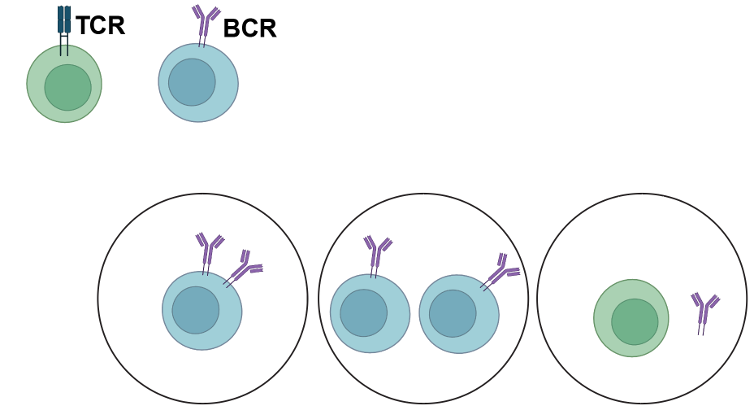

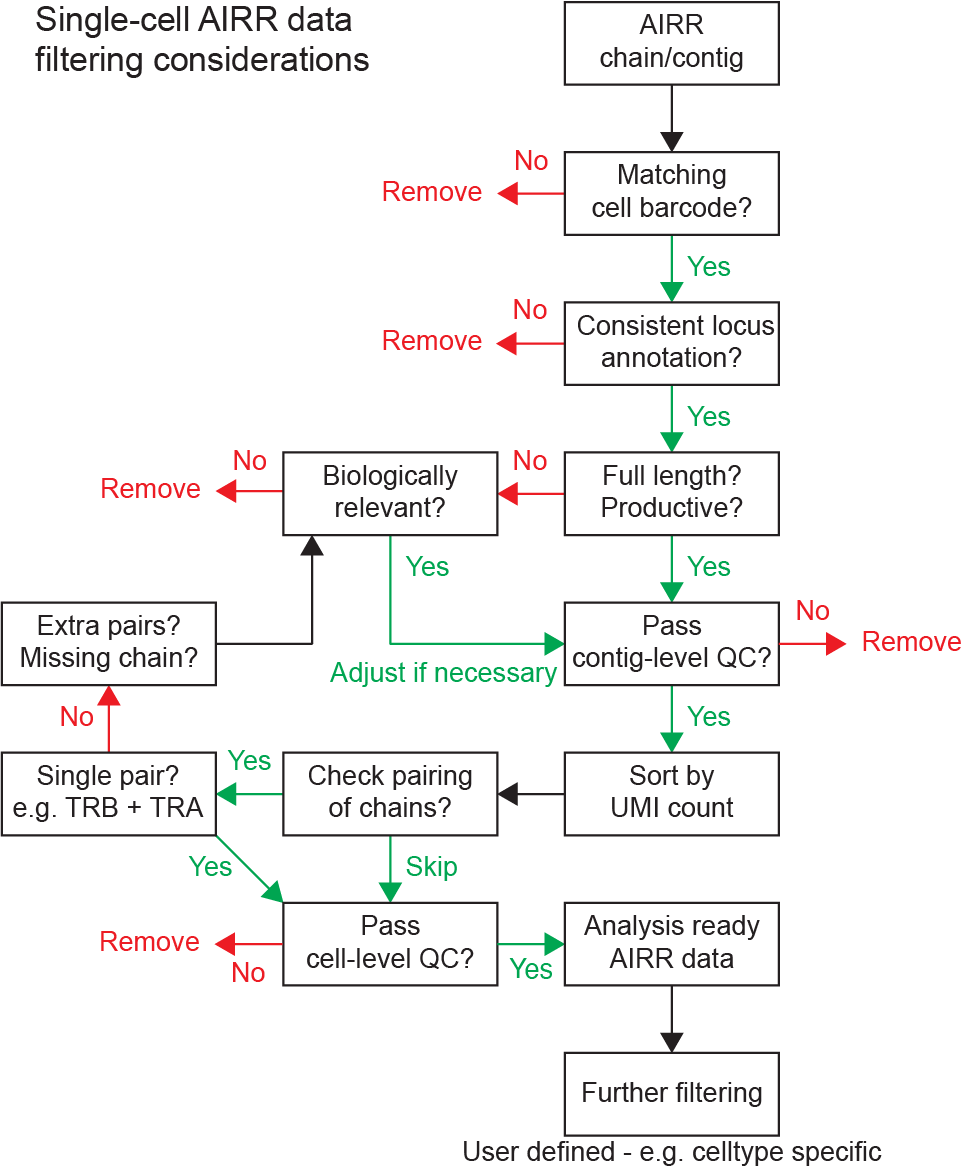

In [21]:
print("Before QC VDJ :", vdj)
vdj, adata = ddl.pp.check_contigs(vdj, adata)
print("After QC VDJ :", vdj)

Before QC VDJ : Lazy Dandelion object with n_obs = 15611 and n_contigs = 39105
    data: cell_id, sequence_id, sequence_length_10x, locus, v_call, d_call, j_call, c_call, productive, junction_aa, junction, consensus_count, umi_count, sequence, rearrangement_status, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, umi_count_VDJ, umi_count_VJ, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_VJ_main, umi_count_VDJ_main, umi_count_VJ_main, chain_status, rearrangement_status_VDJ, rearrangement_status_VJ, sample_id
    metadata: cell_id, sample_id, locus_VDJ, locus_VJ, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, productive_VDJ, productive_VJ, junction_aa_VDJ, junction_aa_VJ, junction_VDJ, junction_VJ, umi_count_VDJ, umi_count_VJ, locus_VDJ_main, locus_VJ_main, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_

IndexError: No contigs passed filtering. Check that cell barcodes match.

In [22]:
vdj._metadata.collect()

cell_id,sample_id,locus_VDJ,locus_VJ,v_call_VDJ,v_call_VJ,d_call_VDJ,j_call_VDJ,j_call_VJ,c_call_VDJ,c_call_VJ,productive_VDJ,productive_VJ,junction_aa_VDJ,junction_aa_VJ,junction_VDJ,junction_VJ,umi_count_VDJ,umi_count_VJ,locus_VDJ_main,locus_VJ_main,v_call_VDJ_main,v_call_VJ_main,d_call_VDJ_main,j_call_VDJ_main,j_call_VJ_main,c_call_VDJ_main,c_call_VJ_main,productive_VDJ_main,productive_VJ_main,junction_aa_VDJ_main,junction_aa_VJ_main,junction_VDJ_main,junction_VJ_main,umi_count_VDJ_main,umi_count_VJ_main,locus_status,chain_status,rearrangement_status_VDJ,rearrangement_status_VJ
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,str,str,str,str
"""AAACCAAAGAAAGTGC-1""","""SeekGene1""","""TRB""","""TRA""","""TRBV2""","""TRAV12-1""",null,"""TRBJ2-7""","""TRAJ4""","""TRBC2""","""TRAC""","""T""","""T""","""CASSGQGNYEQYF""","""CVVSQGGYNKLIF""","""TGTGCCAGCAGTGGACAGGGAAACTACGAG…","""TGTGTGGTGTCCCAAGGCGGCTACAATAAG…",15,7,"""TRB""","""TRA""","""TRBV2""","""TRAV12-1""",null,"""TRBJ2-7""","""TRAJ4""","""TRBC2""","""TRAC""","""T""","""T""","""CASSGQGNYEQYF""","""CVVSQGGYNKLIF""","""TGTGCCAGCAGTGGACAGGGAAACTACGAG…","""TGTGTGGTGTCCCAAGGCGGCTACAATAAG…",15.0,7.0,"""TRB + TRA""","""Single pair""","""Standard""","""Standard"""
"""AAACCAAAGGTCACGT-1""","""SeekGene1""","""TRB""","""TRA""","""TRBV7-2""","""TRAV8-6""",null,"""TRBJ2-3""","""TRAJ18""","""TRBC2""","""TRAC""","""T""","""T""","""CASSLFPEAFTDTQYF""","""CAVNGRGSTLGRLYF""","""TGTGCCAGCAGCTTATTTCCAGAAGCTTTC…","""TGTGCTGTGAATGGTAGAGGCTCAACCCTG…",22,5,"""TRB""","""TRA""","""TRBV7-2""","""TRAV8-6""",null,"""TRBJ2-3""","""TRAJ18""","""TRBC2""","""TRAC""","""T""","""T""","""CASSLFPEAFTDTQYF""","""CAVNGRGSTLGRLYF""","""TGTGCCAGCAGCTTATTTCCAGAAGCTTTC…","""TGTGCTGTGAATGGTAGAGGCTCAACCCTG…",22.0,5.0,"""TRB + TRA""","""Single pair""","""Standard""","""Standard"""
"""AAACCAGCAGTGCGTC-1""","""SeekGene1""","""TRB""","""TRA|TRA""","""TRBV6-6""","""TRAV13-1|TRAV9-2""",null,"""TRBJ1-6""","""TRAJ26|TRAJ22""","""TRBC1""","""TRAC""","""T""","""T|T""","""CASGTPVNSPLHF""","""CAAIPYGQNFVF|CALSDLGGSARQLTF""","""TGTGCCAGCGGGACGCCGGTTAATTCACCC…","""TGTGCAGCAATTCCCTATGGTCAGAATTTT…",13,3,"""TRB""","""TRA""","""TRBV6-6""","""TRAV13-1""",null,"""TRBJ1-6""","""TRAJ26""","""TRBC1""","""TRAC""","""T""","""T""","""CASGTPVNSPLHF""","""CAAIPYGQNFVF""","""TGTGCCAGCGGGACGCCGGTTAATTCACCC…","""TGTGCAGCAATTCCCTATGGTCAGAATTTT…",13.0,1.5,"""Ambiguous""","""Ambiguous""","""Standard""","""Multi"""
"""AAACCAGCAGTTCAGT-1""","""SeekGene1""","""TRB""","""TRA""","""TRBV30""","""TRAV25""","""TRBD1""","""TRBJ1-2""","""TRAJ49""","""TRBC1""","""TRAC""","""T""","""T""","""CAWNTGTGDLNTRANYGYTF""","""CAGGNTGNQFYF""","""TGTGCCTGGAACACCGGGACAGGGGATCTT…","""TGTGCAGGGGGGAACACCGGTAACCAGTTC…",25,2,"""TRB""","""TRA""","""TRBV30""","""TRAV25""","""TRBD1""","""TRBJ1-2""","""TRAJ49""","""TRBC1""","""TRAC""","""T""","""T""","""CAWNTGTGDLNTRANYGYTF""","""CAGGNTGNQFYF""","""TGTGCCTGGAACACCGGGACAGGGGATCTT…","""TGTGCAGGGGGGAACACCGGTAACCAGTTC…",25.0,2.0,"""TRB + TRA""","""Single pair""","""Standard""","""Standard"""
"""AAACCATTCATCAATA-1""","""SeekGene1""","""TRB""","""TRA|TRA""","""TRBV19""","""TRAV35|TRAV8-3""",null,"""TRBJ1-3""","""TRAJ42|TRAJ48""","""TRBC1""","""TRAC|TRAC""","""T""","""T|T""","""CASSLDSSNGNTIYF""","""CAGARSPNYGGSQGNLIF|CAVGLFGNEKL…","""TGTGCCAGTAGCTTGGACTCCTCGAATGGA…","""TGTGCTGGTGCGCGTTCTCCGAATTATGGA…",16,14,"""TRB""","""TRA""","""TRBV19""","""TRAV35""",null,"""TRBJ1-3""","""TRAJ42""","""TRBC1""","""TRAC""","""T""","""T""","""CASSLDSSNGNTIYF""","""CAGARSPNYGGSQGNLIF""","""TGTGCCAGTAGCTTGGACTCCTCGAATGGA…","""TGTGCTGGTGCGCGTTCTCCGAATTATGGA…",16.0,7.0,"""Ambiguous""","""Ambiguous""","""Standard""","""Multi"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GTTGTCTTCACATTGG-1""","""SeekGene2""","""TRB|TRB""","""TRA""","""TRBV5-8|TRBV21-1""","""TRAV41""","""TRBD1""","""TRBJ2-1|TRBJ1-1""","""TRAJ54""","""TRBC2|TRBC1""

In [23]:
adata.obs

,sample_id,cell_type,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,n_genes
SeekGene1_AAACCAAAGAAAGTGC-1,SeekGene1,CD8 naive/Tcm,3208,8.073715,11316.0,9.334062,33.165429,46.482856,55.814776,67.347119,280.0,5.638355,2.474373,3208
SeekGene1_AAACCAAAGAGAGTTA-1,SeekGene1,Non-classical monocyte,4811,8.478868,22100.0,10.003378,24.348416,33.592760,44.235294,59.253394,727.0,6.590301,3.289593,4811
SeekGene1_AAACCAAAGGTCACGT-1,SeekGene1,CD4 naive/Tcm,2794,7.935587,9849.0,9.195227,34.602498,47.598741,57.081937,69.387755,193.0,5.267858,1.959590,2794
SeekGene1_AAACCAGCAACGTTTA-1,SeekGene1,gdT cell,3215,8.075894,9441.0,9.152923,23.440314,33.079123,43.766550,58.690817,271.0,5.605802,2.870459,3215
SeekGene1_AAACCAGCAATCAAGG-1,SeekGene1,gdT cell,3828,8.250359,12843.0,9.460632,23.615978,33.185393,43.432220,57.883672,302.0,5.713733,2.351475,3828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SeekGene2_GTTGTGCAGCAGCCCA-1,SeekGene2,CD4 naive/Tcm,1732,7.457609,5356.0,8.586160,36.930545,51.381628,61.519791,74.738611,117.0,4.770685,2.184466,1732
SeekGene2_GTTGTGGGTAAAGCTC-1,SeekGene2,HSPC,4849,8.486734,19649.0,9.885833,30.154206,43.279556,52.893277,63.199145,517.0,6.249975,2.631177,4849
SeekGene2_GTTGTGGGTCAGGTTG-1,SeekGene2,CD56_dim CD16+ NK,2784,7.932003,7470.0,8.918784,25.863454,34.497992,44.738956,59.879518,272.0,5.609472,3.641232,2784
SeekGene2_GTTGTGGGTCTCCTGG-1,SeekGene2,CD4 naive/Tcm,2238,7.713785,7099.0,8.867850,35.934639,49.894351,59.247781,71.333991,245.0,5.505332,3.451190,2238


In [24]:
vdj1.add_cell_prefix("SeekGene1_")
vdj2.add_cell_prefix("SeekGene2_")
vdj = ddl.tl.concat([vdj1, vdj2])
vdj._metadata.collect()

cell_id,sample_id,locus_VDJ,locus_VJ,v_call_VDJ,v_call_VJ,d_call_VDJ,j_call_VDJ,j_call_VJ,c_call_VDJ,c_call_VJ,productive_VDJ,productive_VJ,junction_aa_VDJ,junction_aa_VJ,junction_VDJ,junction_VJ,umi_count_VDJ,umi_count_VJ,locus_VDJ_main,locus_VJ_main,v_call_VDJ_main,v_call_VJ_main,d_call_VDJ_main,j_call_VDJ_main,j_call_VJ_main,c_call_VDJ_main,c_call_VJ_main,productive_VDJ_main,productive_VJ_main,junction_aa_VDJ_main,junction_aa_VJ_main,junction_VDJ_main,junction_VJ_main,umi_count_VDJ_main,umi_count_VJ_main,locus_status,chain_status,rearrangement_status_VDJ,rearrangement_status_VJ
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,str,str,str,str
"""SeekGene1_AAACCAAAGAAAGTGC-1""","""SeekGene1""","""TRB|TRB""","""TRA""","""TRBV6-1|TRBV20-1""","""TRAV3""","""TRBD2""","""TRBJ2-3|TRBJ1-1""","""TRAJ26""","""TRBC2|TRBC1""","""TRAC""","""T|T""","""T""","""CASSEWASGGTDTQYF|CSARGRPMNTEAF…","""CAVRAHTNYGQNFVF""","""TGTGCCAGCAGTGAATGGGCTAGCGGGGGG…","""TGTGCTGTGAGAGCTCACACTAACTATGGT…",29,10,"""TRB""","""TRA""","""TRBV6-1""","""TRAV3""","""TRBD2""","""TRBJ2-3""","""TRAJ26""","""TRBC2""","""TRAC""","""T""","""T""","""CASSEWASGGTDTQYF""","""CAVRAHTNYGQNFVF""","""TGTGCCAGCAGTGAATGGGCTAGCGGGGGG…","""TGTGCTGTGAGAGCTCACACTAACTATGGT…",14.5,10.0,"""Extra VDJ + TRA""","""Extra pair""","""Multi""","""Standard"""
"""SeekGene1_AAACCAAAGGTCACGT-1""","""SeekGene1""","""TRB|TRB""","""TRA""","""TRBV5-5|TRBV7-9""","""TRAV8-3""",null,"""TRBJ2-5|TRBJ1-6""","""TRAJ38""","""TRBC2|TRBC1""","""TRAC""","""T|T""","""T""","""CASSFGHPQETQYF|CASSSHDGQGVSSPL…","""CAVKPGNNRKLIW""","""TGTGCCAGCAGCTTTGGACACCCACAAGAG…","""TGTGCTGTGAAACCCGGCAACAACCGTAAG…",45,7,"""TRB""","""TRA""","""TRBV5-5""","""TRAV8-3""",null,"""TRBJ2-5""","""TRAJ38""","""TRBC2""","""TRAC""","""T""","""T""","""CASSFGHPQETQYF""","""CAVKPGNNRKLIW""","""TGTGCCAGCAGCTTTGGACACCCACAAGAG…","""TGTGCTGTGAAACCCGGCAACAACCGTAAG…",22.5,7.0,"""Extra VDJ + TRA""","""Extra pair""","""Multi""","""Standard"""
"""SeekGene1_AAACCAGCAGTGCGTC-1""","""SeekGene1""","""TRB""","""TRA|TRA""","""TRBV18""","""TRAV14/DV4|TRAV6""",null,"""TRBJ1-5""","""TRAJ12|TRAJ37""","""TRBC1""","""TRAC|TRAC""","""T""","""T|T""","""CASSPRRDLRPRDSNQPQHF""","""CAMREGQDSSYKLIF|CALGEGSGNTGKLI…","""TGTGCCAGCTCACCCCGCCGGGACCTCCGG…","""TGTGCAATGAGAGAGGGCCAGGATAGCAGC…",13,9,"""TRB""","""TRA""","""TRBV18""","""TRAV14/DV4""",null,"""TRBJ1-5""","""TRAJ12""","""TRBC1""","""TRAC""","""T""","""T""","""CASSPRRDLRPRDSNQPQHF""","""CAMREGQDSSYKLIF""","""TGTGCCAGCTCACCCCGCCGGGACCTCCGG…","""TGTGCAATGAGAGAGGGCCAGGATAGCAGC…",13.0,4.5,"""Ambiguous""","""Ambiguous""","""Standard""","""Multi"""
"""SeekGene1_AAACCAGCAGTTCAGT-1""","""SeekGene1""","""TRB""","""TRA""","""TRBV5-4""","""TRAV23/DV6""",null,"""TRBJ2-7""","""TRAJ36""","""TRBC2""","""TRAC""","""T""","""T""","""CASSGDGYEQYF""","""CAVLTGANNLFF""","""TGTGCCAGCAGCGGTGACGGCTACGAGCAG…","""TGTGCAGTCCTAACTGGGGCAAACAACCTC…",13,9,"""TRB""","""TRA""","""TRBV5-4""","""TRAV23/DV6""",null,"""TRBJ2-7""","""TRAJ36""","""TRBC2""","""TRAC""","""T""","""T""","""CASSGDGYEQYF""","""CAVLTGANNLFF""","""TGTGCCAGCAGCGGTGACGGCTACGAGCAG…","""TGTGCAGTCCTAACTGGGGCAAACAACCTC…",13.0,9.0,"""TRB + TRA""","""Single pair""","""Standard""","""Standard"""
"""SeekGene1_AAACCATTCATCAATA-1""","""SeekGene1""","""TRB|TRB""","""TRA""","""TRBV5-1|TRBV11-3""","""TRAV3""","""TRBD1""","""TRBJ1-2|TRBJ1-1""","""TRAJ37""","""TRBC1|TRBC1""","""TRAC""","""T|T""","""T""","""CASSETGGVYGYTF|CASSLSYTEAFF""","""CAVSDGSSNTGKLIF""","""TGCGCCAGCAGCGAGACAGGGGGGGTCTAT…","""TGTGCTGTGAGCGATGGCTCTAGCAACACA…",25,4,"""TRB""","""TRA""","""TRBV5-1""","""TRAV3""","""TRBD1""","""TRBJ1-2""","""TRAJ37""","""TRBC1""","""TRAC""","""T""","""T""","""CASSETGGVYGYTF""","""CAVSDGSSNTGKLIF""","""TGCGCCAGCAGCGAGACAGGGGGGGTCTAT…","""TGTGCTGTGAGCGATGGCTCTAGCAACACA…",12.5,4.0,"""Extra VDJ + TRA""","""Extra pair""","""Multi""","""Standard"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…

In [25]:
print("Before QC VDJ :", vdj)
vdj, adata = ddl.pp.check_contigs(vdj, adata)
print("After QC VDJ :", vdj)

Before QC VDJ : Lazy Dandelion object with n_obs = 15428 and n_contigs = 39105
    data: cell_id, sequence_id, sequence_length_10x, locus, v_call, d_call, j_call, c_call, productive, junction_aa, junction, consensus_count, umi_count, sequence, rearrangement_status, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, umi_count_VDJ, umi_count_VJ, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_VJ_main, umi_count_VDJ_main, umi_count_VJ_main, chain_status, rearrangement_status_VDJ, rearrangement_status_VJ, sample_id
    metadata: cell_id, sample_id, locus_VDJ, locus_VJ, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, productive_VDJ, productive_VJ, junction_aa_VDJ, junction_aa_VJ, junction_VDJ, junction_VJ, umi_count_VDJ, umi_count_VJ, locus_VDJ_main, locus_VJ_main, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_

In [26]:
# What chain compositions do we see?
adata.obs["chain_status"].value_counts(dropna=False)

,count
chain_status,
NaN,9583
Single pair,8139
Ambiguous,3123
Orphan VDJ,2257
Orphan VJ,1415
Extra pair,308


For the rest of the tutorial we focus on cells with a clean `Single pair`.
These are the healthy αβ T cells where we can confidently link a clonotype to a transcriptomic state.
`NaN` cells without any TCR are also kept in `adata` for the UMAP, but they will appear as "missing" in clone-related plots.

In [27]:
vdj = vdj[vdj.metadata["chain_status"] == "Single pair"]
vdj

Lazy Dandelion object with n_obs = 11955 and n_contigs = 20882
    data: cell_id, sequence_id, sequence_length_10x, locus, v_call, d_call, j_call, c_call, productive, junction_aa, junction, consensus_count, umi_count, sequence, rearrangement_status, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, umi_count_VDJ, umi_count_VJ, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_VJ_main, umi_count_VDJ_main, umi_count_VJ_main, chain_status, rearrangement_status_VDJ, rearrangement_status_VJ, sample_id, extra, ambiguous
    metadata: cell_id, sample_id, locus_VDJ, locus_VJ, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, productive_VDJ, productive_VJ, junction_aa_VDJ, junction_aa_VJ, junction_VDJ, junction_VJ, umi_count_VDJ, umi_count_VJ, locus_VDJ_main, locus_VJ_main, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_cal

## Define clonotypes

A clonotype groups cells that descended from the same T cell ancestor.

For TCR data, the standard definition is: identical V gene + identical J gene + identical CDR3 amino-acid sequence on the matched chains. (TCRs don't undergo somatic hypermutation, unlike BCRs, so identity is the natural cutoff.)

Dandelion's `find_clones` implements this directly.

In [28]:
ddl.tl.find_clones(vdj)

meta = vdj.metadata.collect()
clones = (
    meta.group_by("clone_id")
    .agg(pl.len().alias("n_cells"))
    .sort("n_cells", descending=True)
)
clones

Using NumPy backend (CPU only)


Finding clones based on abT cell VDJ chains using junction: 100%|██████████| 2821/2821 [00:00<00:00, 2866.44it/s]
Finding clones based on abT cell VJ chains using junction: 100%|██████████| 5088/5088 [00:01<00:00, 3523.57it/s]
Building distance matrix (batched): 100%|██████████| 80/80 [00:00<00:00, 1111.99it/s]


clone_id,n_cells
str,u32
"""None""",130
"""abT_VDJ_348_3_2_VJ_566_2_1""",27
"""abT_VDJ_310_3_8_VJ_362_3_1""",22
"""abT_VDJ_341_3_1_VJ_39_1_1""",18
"""abT_VDJ_348_3_2""",18
…,…
"""abT_VDJ_351_3_1""",1
"""abT_VDJ_264_6_1""",1
"""abT_VDJ_546_5_2""",1


## Quantify clonal expansion

Once we have clonotypes, we want to know how big each one is. Dandelion's `clone_size` adds three new columns to `vdj.metadata`:

- `clone_id_size`: the raw cell count for each clone
- `clone_id_size_prop`: the same as a proportion of all cells
- `clone_id_size_category`: a standard binning into Rare, Small, Medium, Large, Hyperexpanded, matching the scRepertoire convention.

Passing `max_size=3` adds another column that caps the size at 3 (`clone_id_size_max_3`). Together with the categorical column, these options make downstream plots much more readable.

In [29]:
ddl.tl.clone_size(vdj)

meta = vdj.metadata.collect()
meta.select(
    [
        "clone_id",
        "clone_id_size",
        "clone_id_size_prop",
        "clone_id_size_category",
    ]
).head()

clone_id,clone_id_size,clone_id_size_prop,clone_id_size_category
str,f64,f64,str
"""abT_VDJ_422_6_4_VJ_1051_4_1""",1.0,0.000084,"""Rare"""
"""abT_VJ_1579_1_1""",1.0,0.000084,"""Rare"""
"""abT_VDJ_157_7_1""",1.0,0.000084,"""Rare"""
"""abT_VDJ_375_2_1_VJ_753_1_1""",1.0,0.000084,"""Rare"""
"""abT_VDJ_351_4_7_VJ_1063_2_1""",1.0,0.000084,"""Rare"""


In [30]:
meta["clone_id_size_category"].value_counts()

clone_id_size_category,count
str,u32
null,130
"""Rare""",10532
"""Small""",1165
"""Medium""",128


In [31]:
ddl.tl.clone_size(vdj, max_size=3)  # adds 'clone_id_size_max_3'
meta = vdj.metadata.collect()
meta["clone_id_size_max_3"].value_counts()


clone_id_size_max_3,count
str,u32
""">= 3""",685
null,130
"""1""",10532
"""2""",608


## Build the clonotype network

A clonotype network is a graph where each node is a cell and edges connect cells in the same clonotype. Expanded clonotypes form large connected clusters, whereas singleton clonotypes appear as isolated nodes. `generate_network` constructs this graph and computes a layout for visualisation.

In [32]:
ddl.tl.generate_network(vdj, key="junction")

## Integrate Dandelion into the AnnData

The generated network is stored within the Dandelion object. Since `ddl.pl.clone_network` operates on an AnnData object, we first use `ddl.tl.transfer` to transfer the repertoire annotations, graph structure, and layout coordinates from Dandelion to the matching AnnData. This will push `vdj.metadata` columns into `adata.obs`, and the network's layout + graph into `adata.obsm` / `adata.obsp`.

In [33]:
ddl.tl.transfer(adata, vdj)
adata

AnnData object with n_obs × n_vars = 24825 × 1000
    obs: 'sample_id', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'has_contig', 'locus_VDJ', 'locus_VJ', 'v_call_VDJ', 'v_call_VJ', 'd_call_VDJ', 'j_call_VDJ', 'j_call_VJ', 'c_call_VDJ', 'c_call_VJ', 'productive_VDJ', 'productive_VJ', 'junction_aa_VDJ', 'junction_aa_VJ', 'junction_VDJ', 'junction_VJ', 'umi_count_VDJ', 'umi_count_VJ', 'locus_VDJ_main', 'locus_VJ_main', 'v_call_VDJ_main', 'v_call_VJ_main', 'd_call_VDJ_main', 'j_call_VDJ_main', 'j_call_VJ_main', 'c_call_VDJ_main', 'c_call_VJ_main', 'productive_VDJ_main', 'productive_VJ_main', 'junction_aa_VDJ_main', 'junction_aa_VJ_main', 'junction_VDJ_main', 'junction_VJ_main', 'umi_count_VDJ_main', 'umi_count_VJ_main', 'locus_status', 'chain_

## Visualize clonal expansion

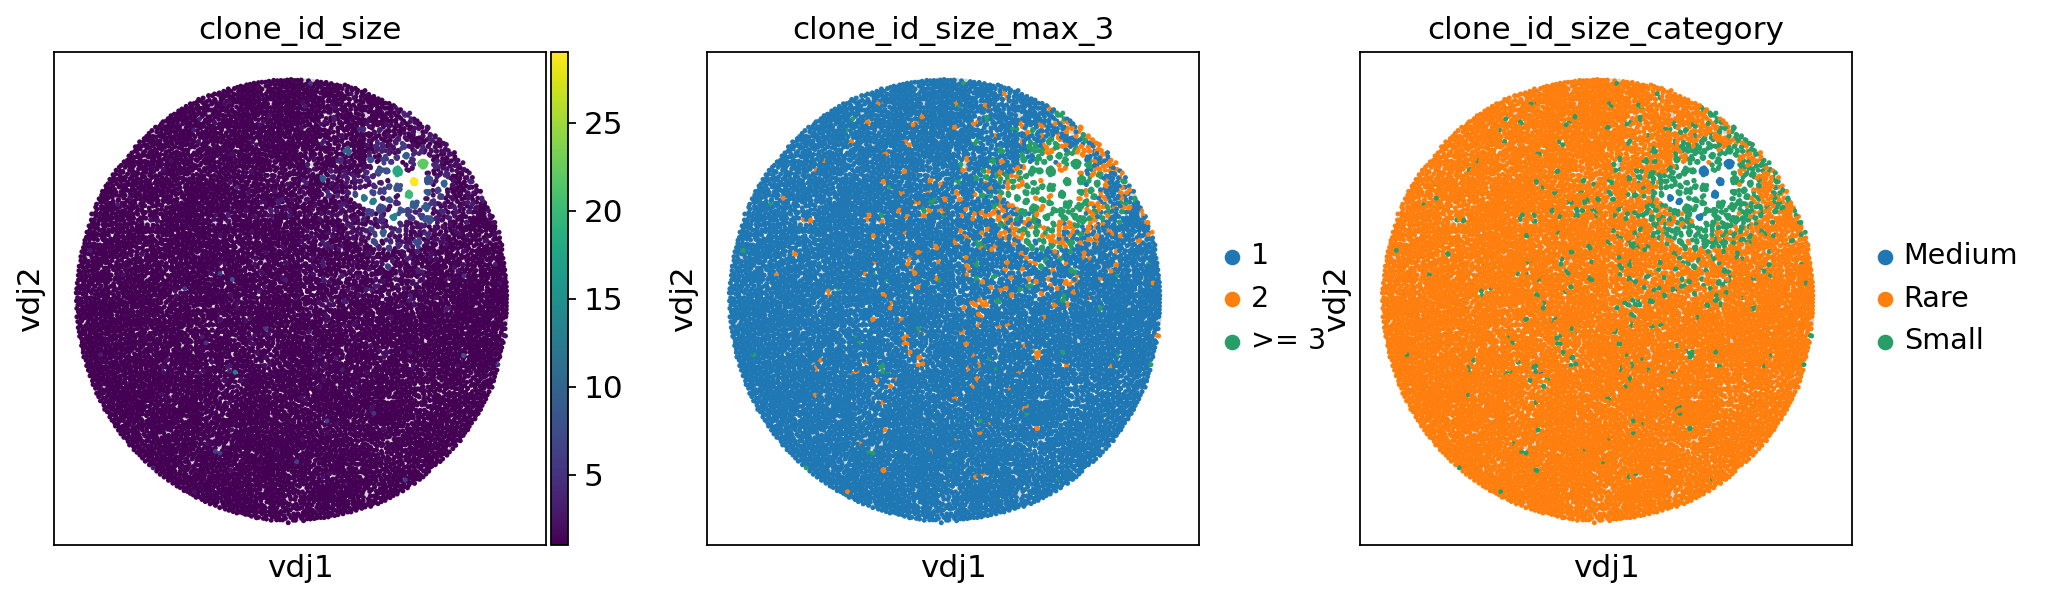

In [34]:
sc.set_figure_params(figsize=[4, 4])
ddl.pl.clone_network(
    adata,
    color=["clone_id_size", "clone_id_size_max_3", "clone_id_size_category"],
    edges_width=1,
    size=20,
    na_in_legend=False,
)

### Zooming in on expanded clones only

`ddl.tl.clone_view(adata, mode="expanded")` switches the active embedding to one that contains only cells in clones with >1 cell, making expansion patterns much easier to see. Switch back with `mode="all"` (or `mode="rna"` to use the original GEX UMAP).

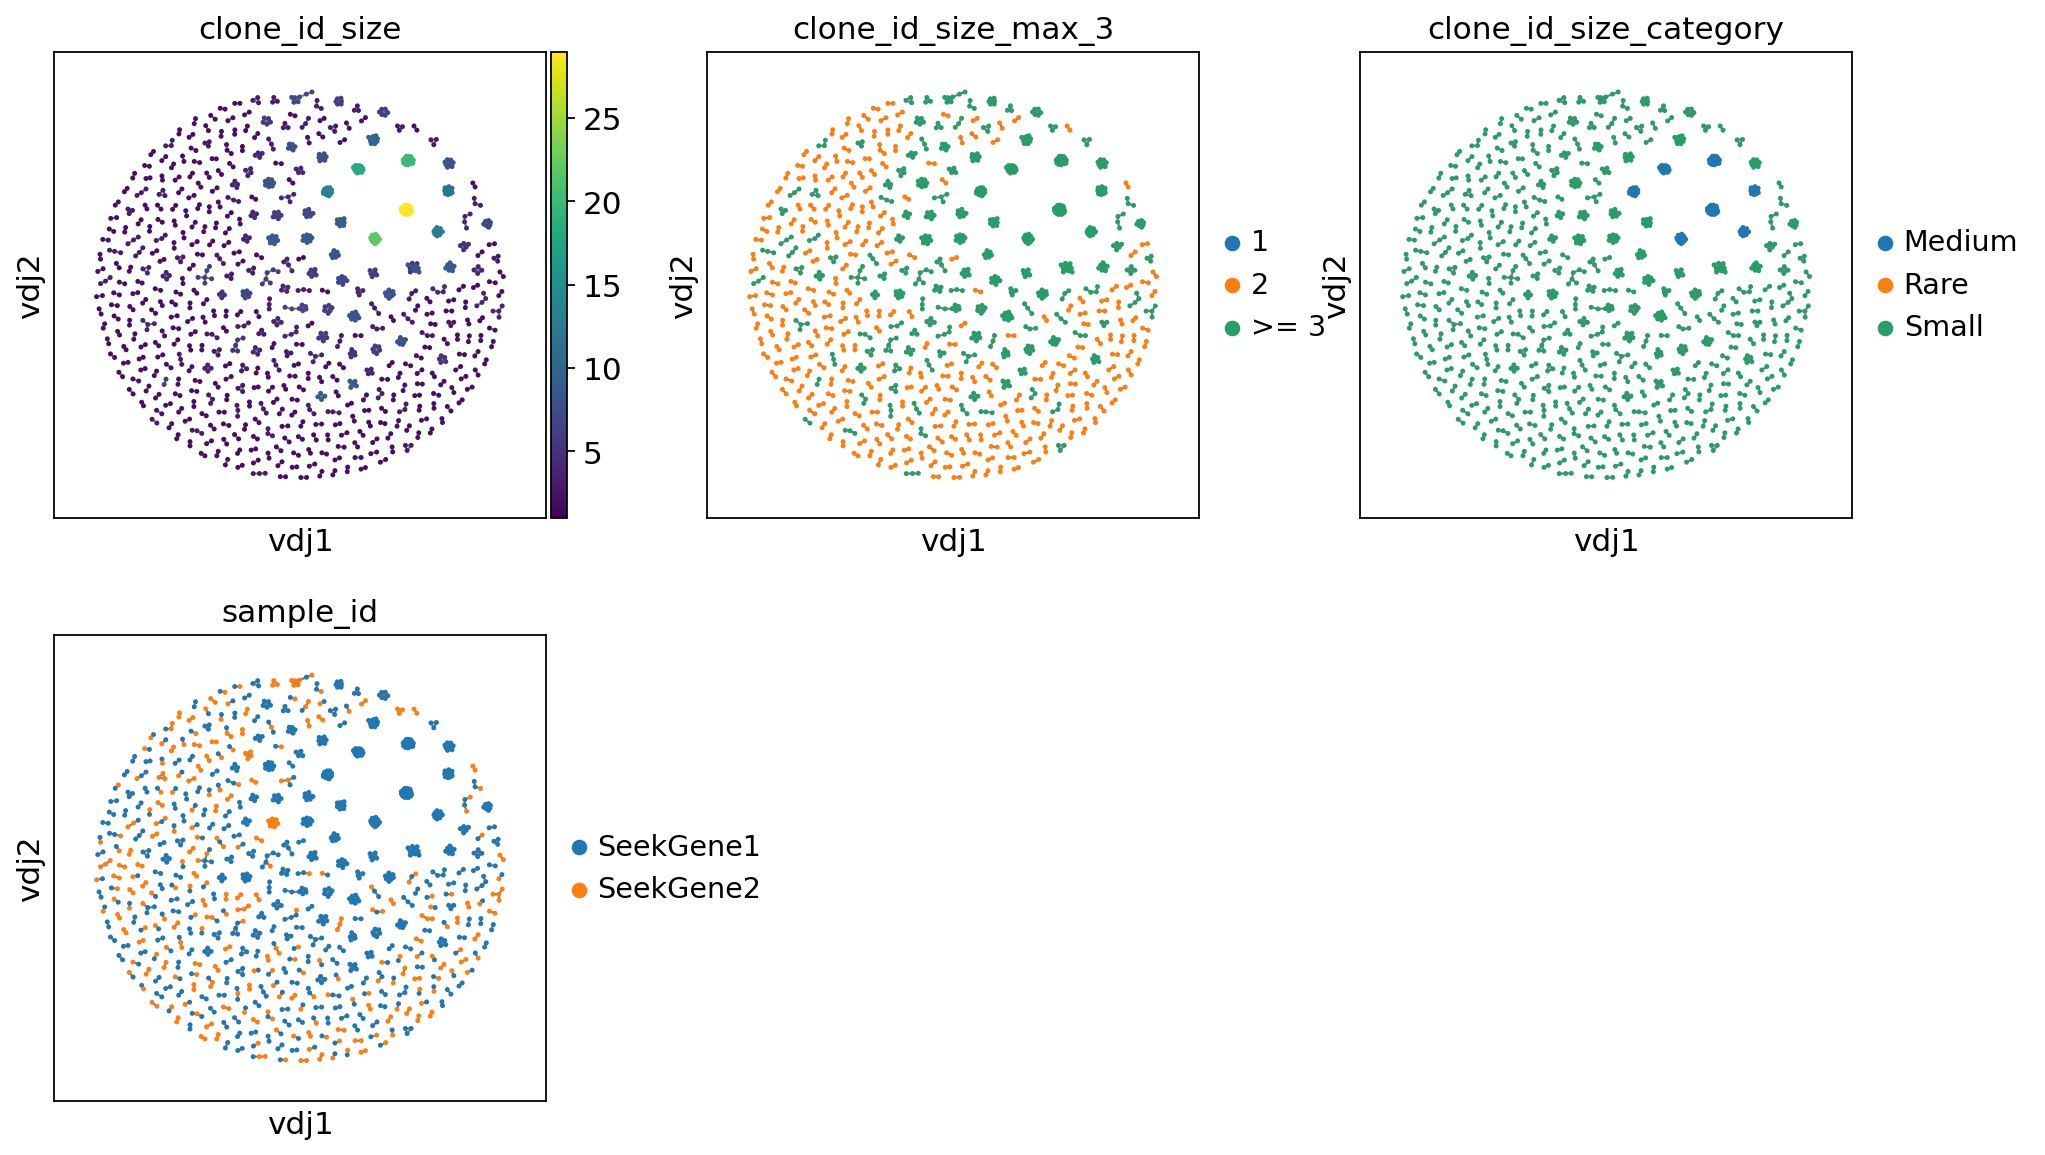

In [35]:
ddl.tl.clone_view(adata, mode="expanded")

ddl.pl.clone_network(
    adata,
    color=["clone_id_size", "clone_id_size_max_3", "clone_id_size_category", "sample_id"],
    edges_width=1,
    ncols=3,
    size=20,
    na_in_legend=False,
)

### Bring in gene expression

Now we layer GEX onto this.

Cells sharing the same TCR have likely responded to the same antigen. Colour the UMAP by expansion category so that singletons, small clones, and large clones are easy to distinguish. Non-T cells (no TCR) appear as grey background.

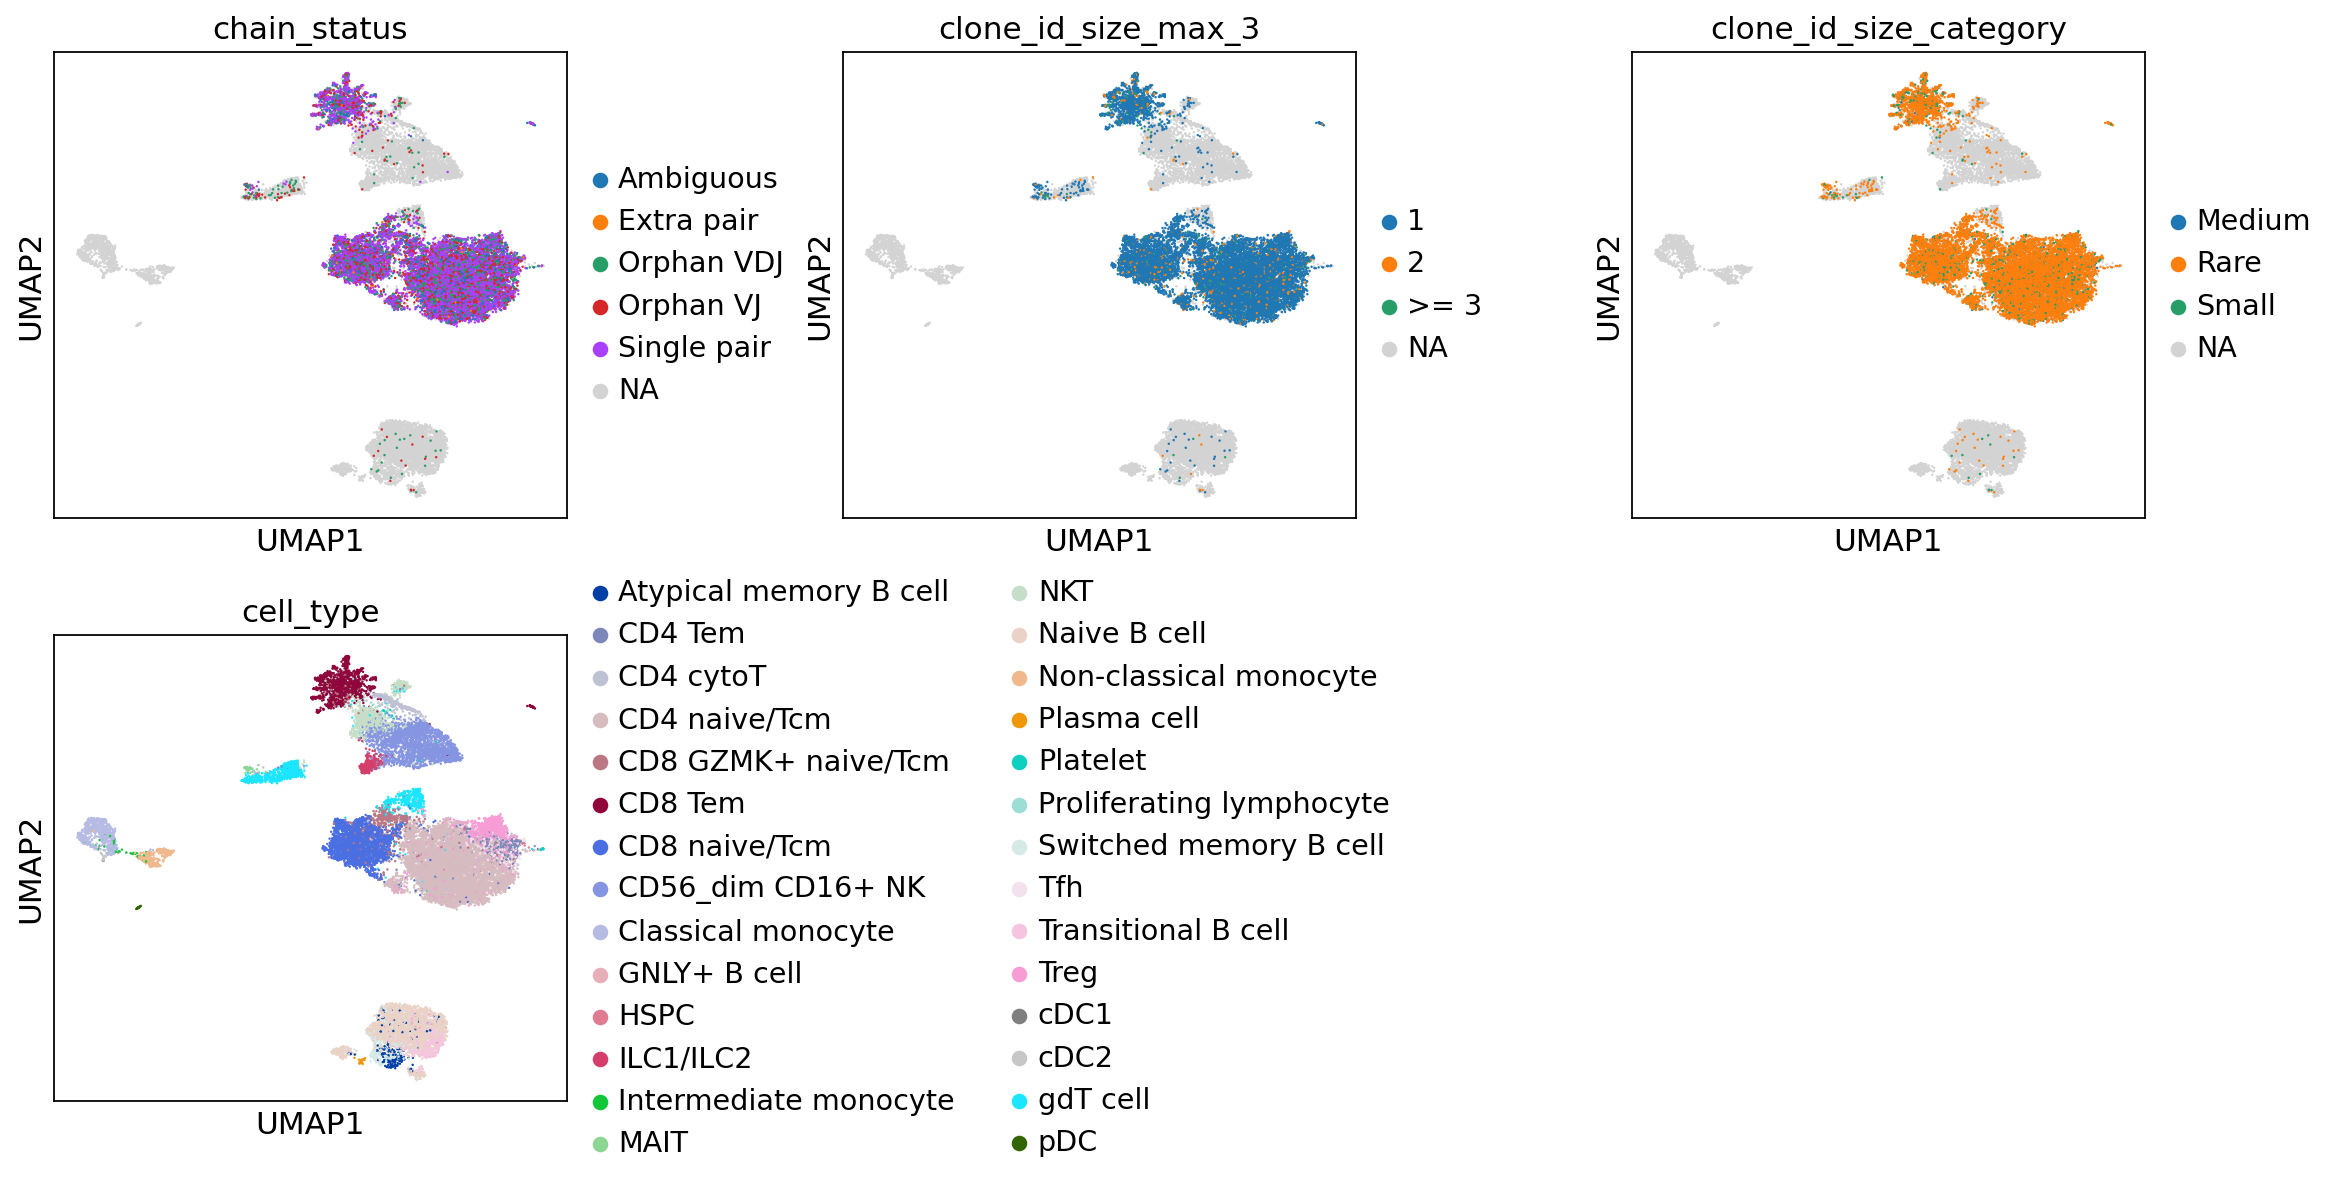

In [36]:
sc.pl.umap(
    adata,
    color=["chain_status", "clone_id_size_max_3", "clone_id_size_category", "cell_type"],
    ncols=3,
    wspace=0.4,
)

### Map TCRs to known specificity

In [37]:
ddl.tl.get_epitope(vdj, adata)

Cells with matched epitope (vdjdb): 368 / 24825


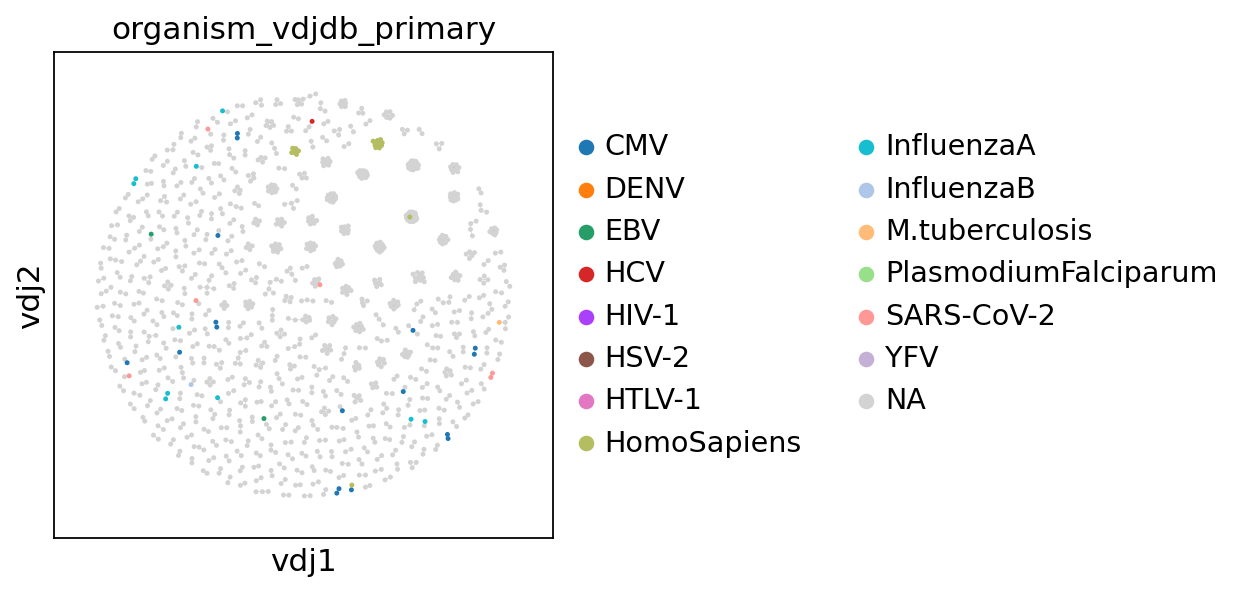

In [41]:
ddl.pl.clone_network(adata, color = "organism_vdjdb_primary", size = 20, edges =1)

In [48]:
adata[adata.obs["organism_vdjdb_primary"] == "CMV"].obs[["clone_id", "clone_id_size", "epitope_vdjdb","organism_vdjdb","epitope_vdjdb_primary","organism_vdjdb_primary"]].sort_values("clone_id_size", ascending=False)


,clone_id,clone_id_size,epitope_vdjdb,organism_vdjdb,epitope_vdjdb_primary,organism_vdjdb_primary
SeekGene1_ATACTAATCGCGGCTA-1,abT_VJ_36_1_1,3.0,NLVPMVATV,CMV,NLVPMVATV,CMV
SeekGene1_ACCTTTCAGGGGGTAC-1,abT_VJ_173_1_1,2.0,NLVPMVATV,CMV,NLVPMVATV,CMV
SeekGene1_ATAACCCCACGATGTT-1,abT_VDJ_419_3_2_VJ_684_1_1,2.0,NLVPMVATV,CMV,NLVPMVATV,CMV
SeekGene1_AGTCGGCGTAAGGCCC-1,abT_VDJ_427_2_1,2.0,FRCPRRFCF,CMV,FRCPRRFCF,CMV
SeekGene1_CTCGAACAGGTAATAG-1,abT_VDJ_419_3_2_VJ_684_1_1,2.0,NLVPMVATV,CMV,NLVPMVATV,CMV
...,...,...,...,...,...,...
SeekGene2_GGTCAATGTCAGGTAT-1,abT_VJ_1453_1_1|abT_VJ_487_1_1,1.0,NLVPMVATV,CMV,NLVPMVATV,CMV
SeekGene2_GGTTGATGTGTAACGT-1,abT_VJ_1360_1_1,1.0,NLVPMVATV,CMV,NLVPMVATV,CMV
SeekGene2_GGTTTGGGTACTCCCG-1,abT_VDJ_447_4_1_VJ_36_1_1,1.0,NLVPMVATV,CMV,NLVPMVATV,CMV
SeekGene2_GTCGGGTGTCATGGGC-1,abT_VJ_1607_1_1,1.0,NLVPMVATV,CMV,NLVPMVATV,CMV


## Summary

In this tutorial we added TCR information to single-cell data:

1. Met the biology and the file formats coming out of a 10x/SeekGene V(D)J run
2. Loaded GEX (`.h5ad`) and VDJ (`.zipddl`)
3. Explored the one row per contig AIRR table
4. QC'd contigs with `ddl.pp.check_contigs`
5. Defined clonotypes with `ddl.tl.find_clones`
6. Quantified expansion with `ddl.tl.clone_size`
7. Built a clonotype network with `ddl.tl.generate_network`
8. Transferred TCR info into the GEX AnnData with `ddl.tl.transfer`
9. Visualised the network via `ddl.tl.clone_view` and `ddl.pl.clone_network`
10. Layered TCR features on the GEX UMAP
11. Compared two samples with `ddl.pl.clone_circlepackplot`

Key takeaways
- `vdj.data`: long, one row per contig (the AIRR table), polars LazyFrame
- `vdj.metadata`: wide, one row per cell, chains summarised, polars LazyFrame
- `adata.obs`: gains `clone_id`, `clone_id_size`, `chain_status`, … (pandas)

Read more here:
https://www.nature.com/articles/s41592-024-02243-4